In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df_cleaned = pd.read_csv('movies_filtered.csv')
df_cleaned

,title,year,rating,votes,runtime,certificate,genre,gross_total,different_ratings,star_rating
0,The Shawshank Redemption,1994,9.3,"3,168,010",142,R,Drama,$29.33M,9.3R,4 and a half stars
1,The Godfather,1972,9.2,"2,212,884",175,R,"Crime, Drama",$250.93M,9.2R,4 and a half stars
2,The Dark Knight,2008,9.1,"3,145,646",152,PG-13,"Action, Crime, Drama",$1008.48M,9.1PG-13,4 and a half stars
3,The Godfather Part II,1974,9.0,"1,486,878",202,R,"Crime, Drama",$48.20M,9.0R,4 and a half stars
4,12 Angry Men,1957,9.0,"977,359",96,Unrated,"Crime, Drama",$0.01M,9.0Unrated,4 and a half stars
...,...,...,...,...,...,...,...,...,...,...
245,Drishyam,2015,8.2,"107,875",163,Unrated,"Crime, Drama, Mystery",$0.01M,8.2Unrated,4 stars
246,The Grapes of Wrath,1940,8.1,"108,041",129,Unrated,Drama,$0.01M,8.1Unrated,4 stars
247,To Be or Not to Be,1942,8.1,"49,586",99,Unrated,"Comedy, Romance, War",$0.00M,8.1Unrated,4 stars
248,Gangs of Wasseypur,2012,8.2,"113,517",321,Unrated,"Action, Comedy, Crime",$4.38M,8.2Unrated,4 stars


In [18]:
print(df_cleaned['certificate'].unique())

['R' 'PG-13' 'Unrated' 'PG' 'G' 'NC-17']


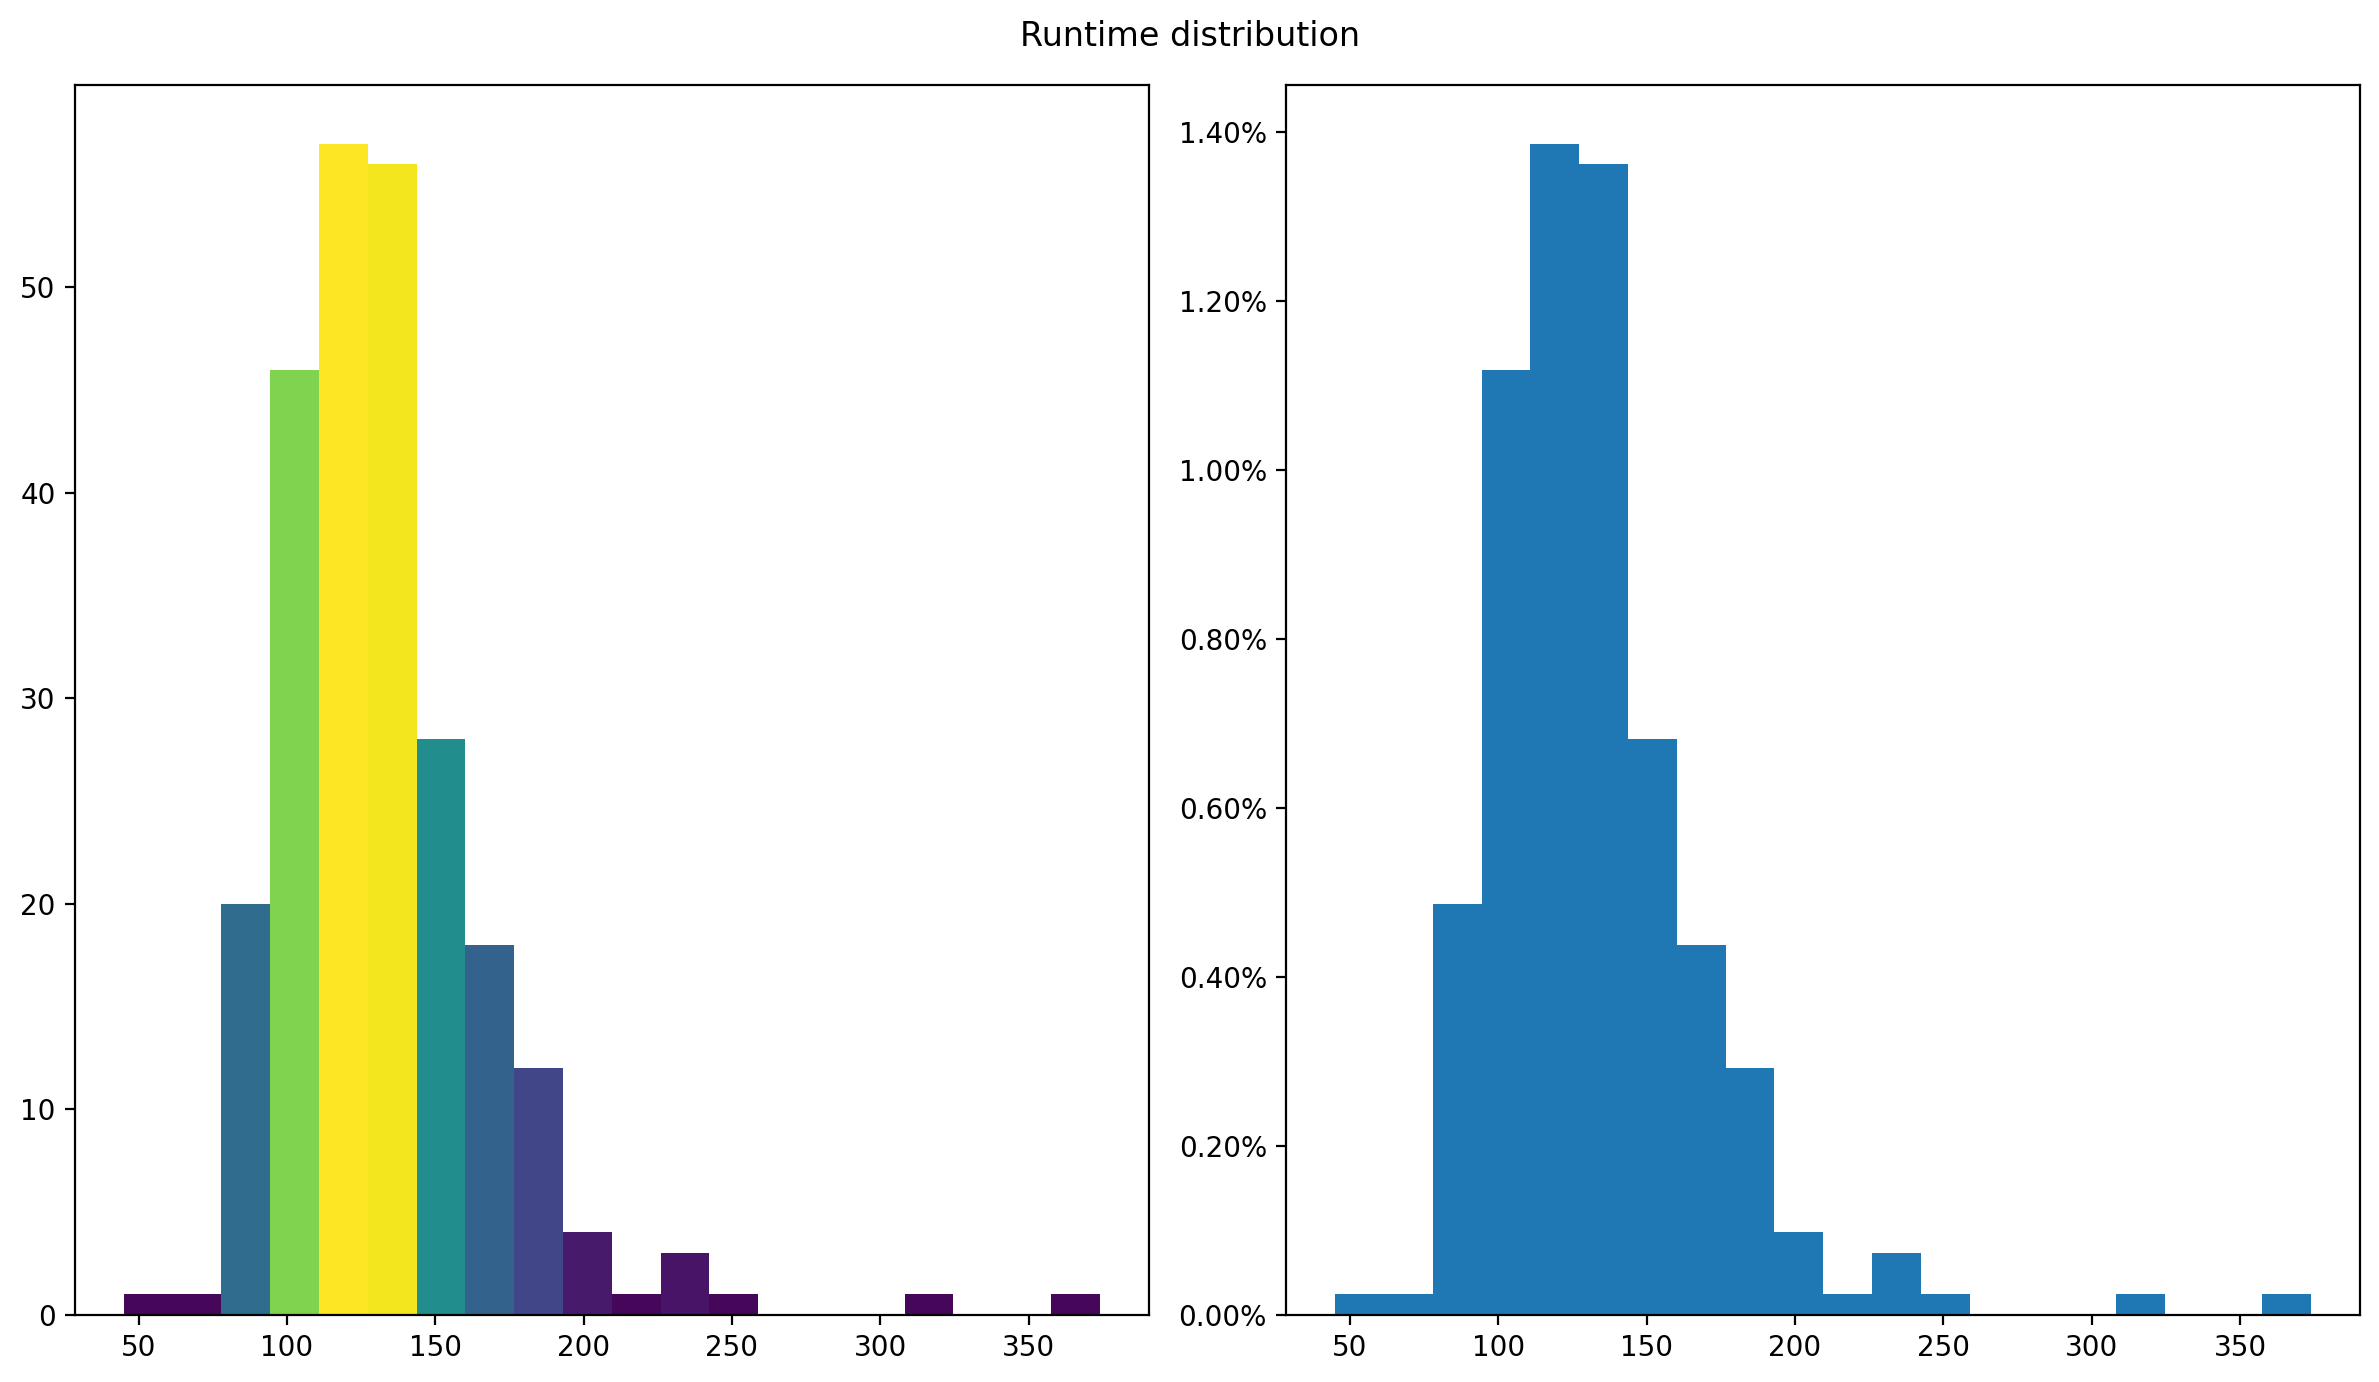

In [6]:
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

dist1 = df_cleaned['runtime']
n_bins = 20

fig, axs = plt.subplots(1, 2, tight_layout=True)

N, bins, patches = axs[0].hist(dist1, bins=n_bins)
fracs = N / N.max()
norm = colors.Normalize(fracs.min(), fracs.max())
for thisfrac, thispatch in zip(fracs, patches):
    color = plt.cm.viridis(norm(thisfrac))
    thispatch.set_facecolor(color)
axs[1].hist(dist1, bins=n_bins, density=True)
axs[1].yaxis.set_major_formatter(PercentFormatter(xmax=1))

plt.suptitle('Runtime distribution')
plt.savefig('hist_runtime.jpg')
plt.show()

In [19]:
print(df_cleaned['certificate'].unique())

['R' 'PG-13' 'Unrated' 'PG' 'G' 'NC-17']


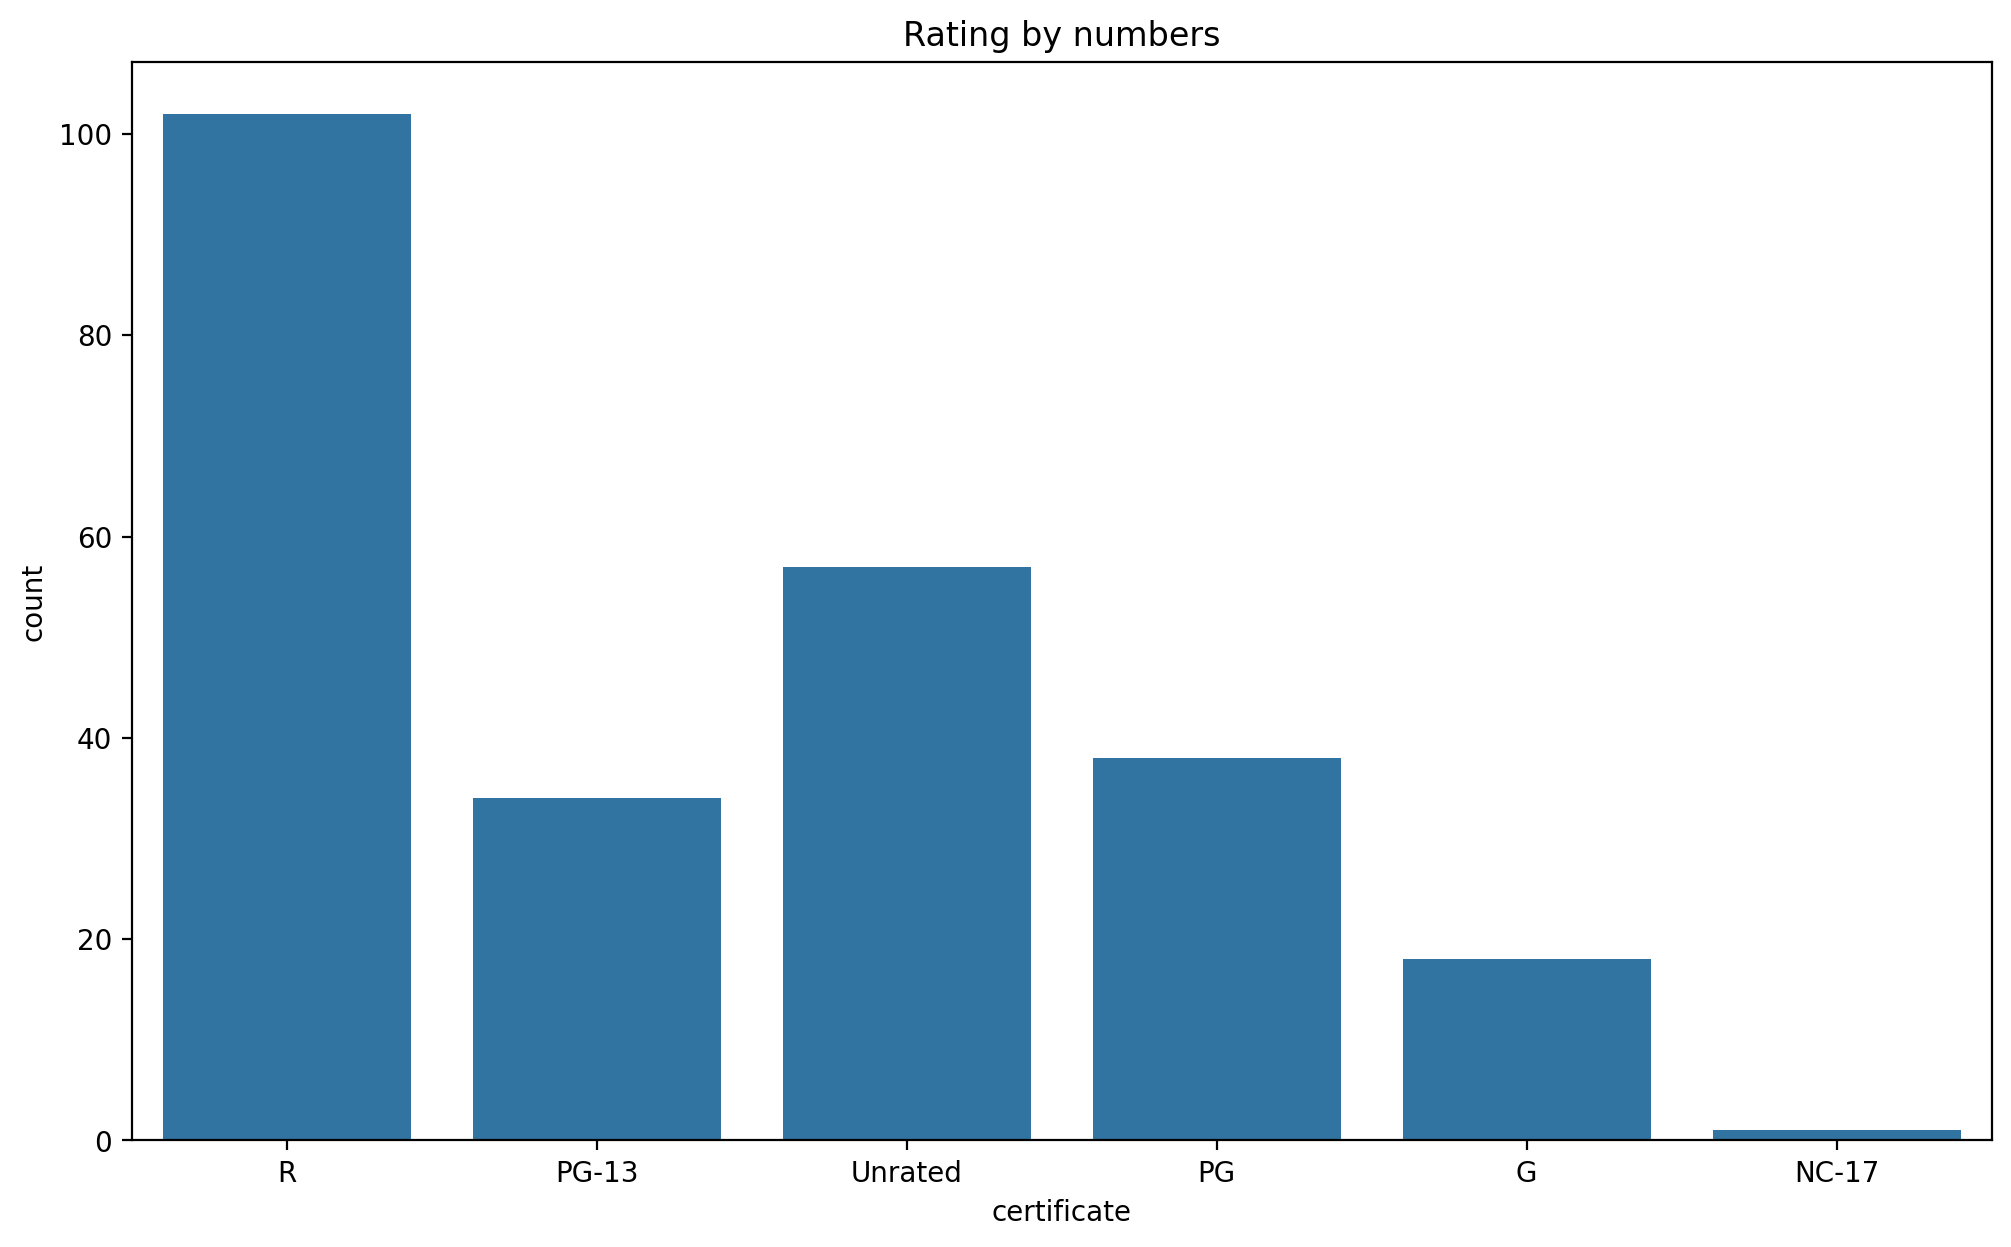

In [22]:
sns.countplot(x='certificate', data=df_cleaned)
plt.title('Rating by numbers')
plt.ylabel('count')
plt.savefig('count_rating.jpg')
plt.show()

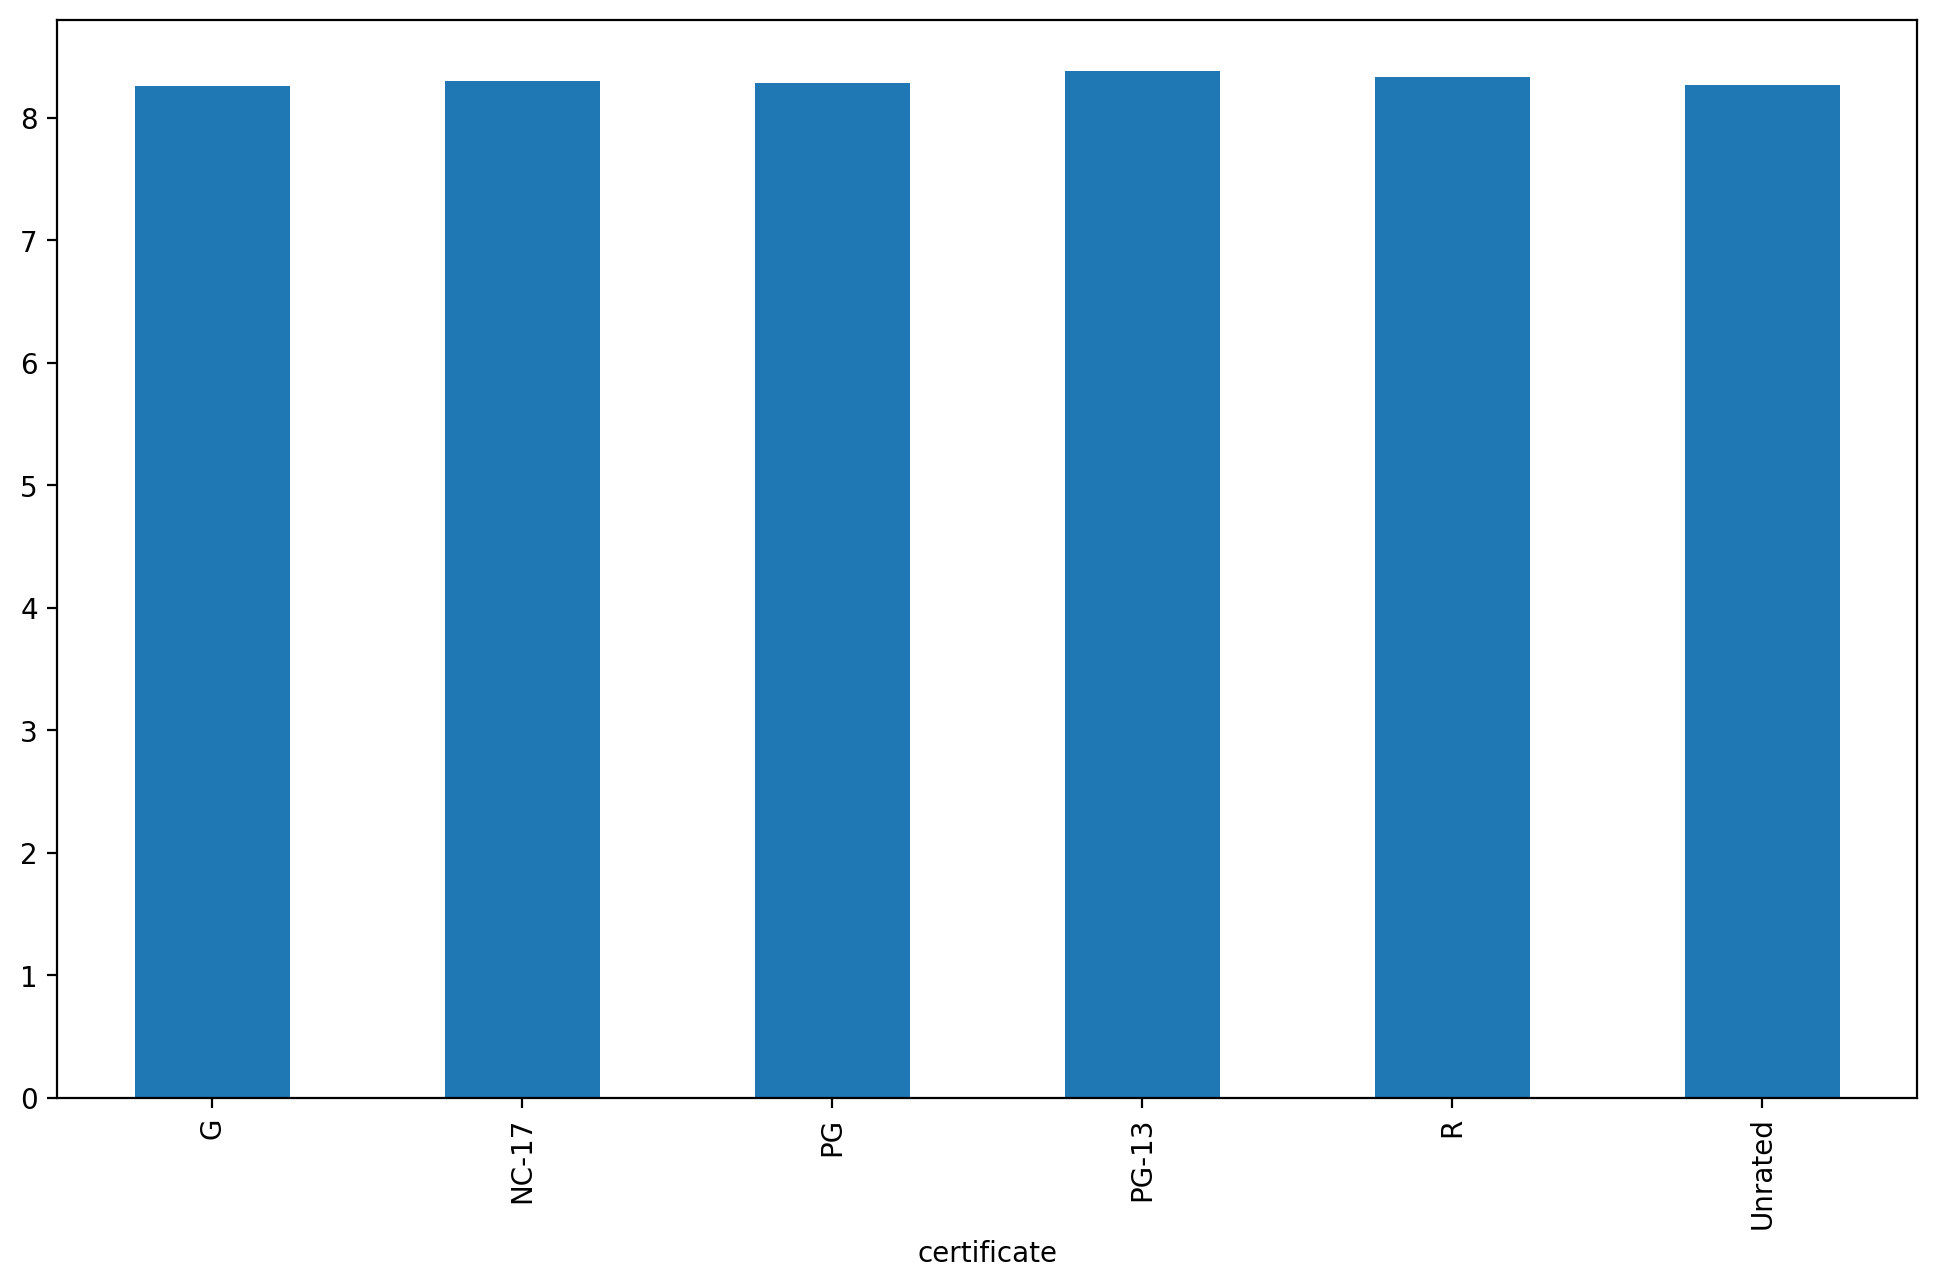

In [7]:
certificateby_rating=df_cleaned.groupby('certificate',observed=True)['rating'].mean()
certificateby_rating.plot(kind='bar')
plt.savefig('count_certif_rating.jpg')

In [8]:
# From this I see that all movies across content ratings have similar enjoyment ratings

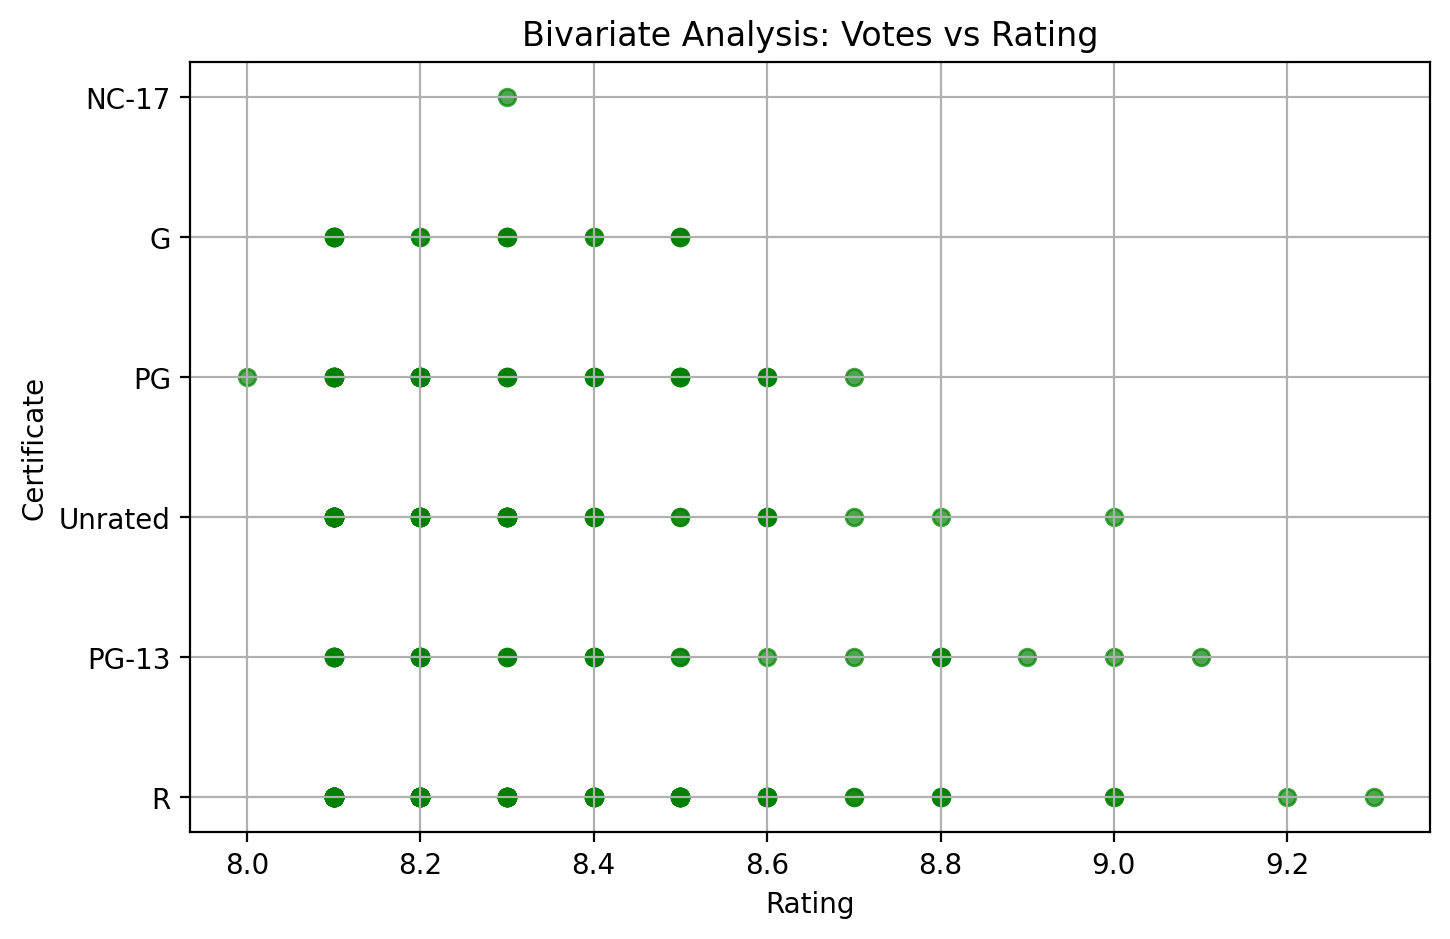

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df_cleaned['rating'], df_cleaned['certificate'], alpha=0.7, color='green')
plt.title('Bivariate Analysis: Votes vs Rating')
plt.xlabel('Rating')
plt.ylabel('Certificate')
plt.grid(True)
plt.show()